# In Class Demo

Plot sin(x), the gradient of sin(x), and compare it to cos(x)

In [71]:
import numpy as np
import math
import matplotlib.pyplot as plt
import scipy as sp

In [43]:
pi = math.pi
n = 5
x = np.linspace(0, (2 * pi), n)

In [44]:
h = x[1] - x[0]

In [45]:
g = np.sin(x)
f = np.cos(x)

In [46]:
grad = np.gradient(g, h)

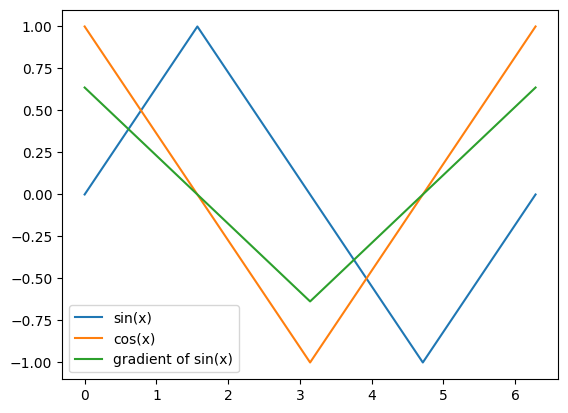

In [47]:
# plot sin(x) and its gradient
plt.plot(x, g, label='sin(x)')
plt.plot(x, f, label='cos(x)')
plt.plot(x, grad, label="gradient of sin(x)")
plt.legend()


Now, develop our own custom solver in a non-elegent way. This is second order accurate approximation.

In [58]:
def gradient_custom(f, h, n):
    grad = np.zeros(n)
    for i in range(n):
    # left endpoint
        if i == 0:
            fg = (-3 * f[i] + 4 * f[i + 1] - f[i + 2]) / (2 * h)
            grad[i] = fg

    # right endpoint
        elif i == n - 1:
            fg = (3 * f[i] - 4 * f[i - 1] + f[i - 2]) / (2 * h)
            grad[i] = fg

    # internal points
        else:
            fg = (f[i + 1] - f[i - 1]) / (2 * h)
            grad[i] = fg
            
    return grad


In [65]:
f_grad = gradient_custom(g, h, n)

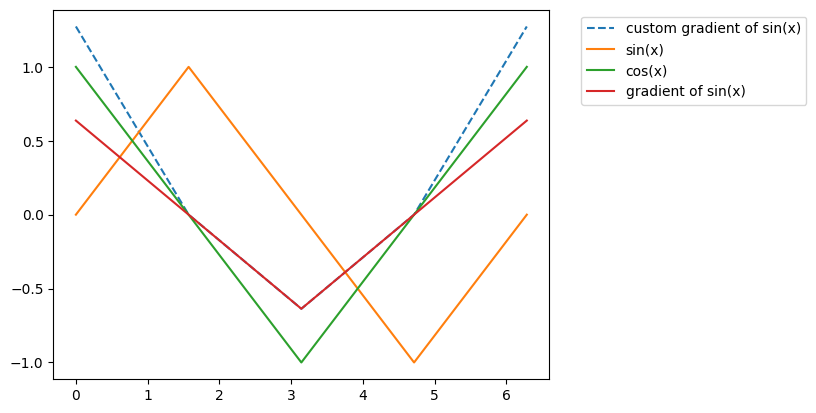

In [67]:
# plot custom gradient
plt.plot(x, f_grad, label="custom gradient of sin(x)", linestyle='dashed')
plt.plot(x, g, label='sin(x)')
plt.plot(x, f, label='cos(x)')
plt.plot(x, grad, label="gradient of sin(x)")
# legend on the right outside of the plot
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

More elegent solution using matrix multiplication

In [80]:
e = np.ones(n)
D = sp.sparse.diags([-e, e], [-1, 1], shape=(n, n)) / (2 * h)
D = D.tolil()
D[0, 0:3] = np.array([-3, 4, -1]) / (2 * h)
D[n - 1, n - 3:n] = np.array([1, -4, 3]) / (2 * h)
print(D.toarray())

[[-0.95492966  1.27323954 -0.31830989  0.          0.        ]
 [-0.31830989  0.          0.31830989  0.          0.        ]
 [ 0.         -0.31830989  0.          0.31830989  0.        ]
 [ 0.          0.         -0.31830989  0.          0.31830989]
 [ 0.          0.          0.31830989 -1.27323954  0.95492966]]
